# Visualise dt vs. distance and x,y with counterplot dt

You must first execute the **plot_dist_vs_dt.ipynb** script and generate for all lines their own **grouped_mean_std_HS??.csv** files. After that you can execute this script. 

### Load modules

In [1]:
import numpy as np
import pandas as pd
import math

import glob
import os

import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec

from obspy import read, UTCDateTime

from scipy.fftpack import fft, fftfreq, next_fast_len

%load_ext autoreload
%autoreload 2
%matplotlib inline 
%matplotlib widget

In [2]:
# put in two hammer strike numbers to compare 
hs_to_compare = ["HS08", "HS09", "HS10", "HS11", "HS12", "HS13"]

# path to where the grouped_mean_std_HS*.csv files are
path_to_grouped_files = "../HS_WEDNESDAY_GROUP/"

path_to_all_files = []
for hs in hs_to_compare:
    path_to_all_files.append(os.path.join(path_to_grouped_files, f"grouped_mean_std_{hs}.csv"))

print(len(path_to_all_files), "files found:\n")

dataframes = []
for path in path_to_all_files:
    print(path)
    df = pd.read_csv(path)
    dataframes.append(df)

big_df = pd.concat(dataframes, ignore_index=True)
big_df.head()


6 files found:

../HS_WEDNESDAY_GROUP/grouped_mean_std_HS08.csv
../HS_WEDNESDAY_GROUP/grouped_mean_std_HS09.csv
../HS_WEDNESDAY_GROUP/grouped_mean_std_HS10.csv
../HS_WEDNESDAY_GROUP/grouped_mean_std_HS11.csv
../HS_WEDNESDAY_GROUP/grouped_mean_std_HS12.csv
../HS_WEDNESDAY_GROUP/grouped_mean_std_HS13.csv


,Unnamed: 0,distance_to_source,mean,std,lon,lat,ev_lat,ev_lon,phase,orientation,sta,experiment
0,0,1.0,0.000000,0.000000,-3.0,2.0,2.0,-4.0,P,Horizontal,39175,HS08
1,1,2.0,0.004506,0.000569,-2.0,2.0,2.0,-4.0,P,Horizontal,33345,HS08
2,2,3.0,0.010334,0.003585,-1.0,2.0,2.0,-4.0,P,Horizontal,31500,HS08
3,3,4.0,0.014360,0.003817,0.0,2.0,2.0,-4.0,P,Horizontal,33116,HS08
4,4,5.0,0.018056,0.004008,1.0,2.0,2.0,-4.0,P,Horizontal,31786,HS08


### Line Plot

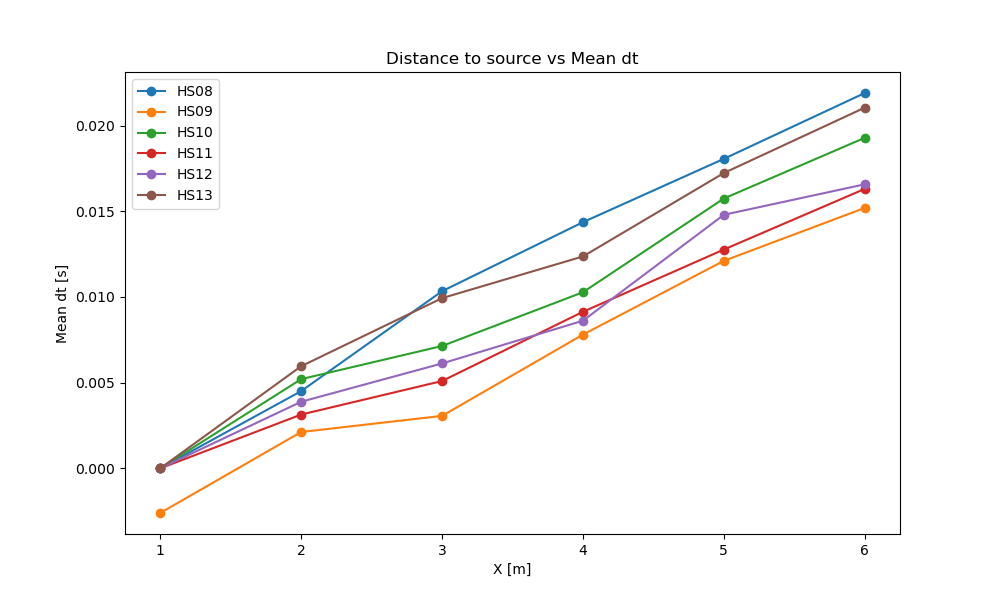

In [3]:
# Create a colormap
cmap = plt.get_cmap('tab10')  # You can choose other colormaps like 'viridis', 'plasma', etc.

colors = {station: cmap(i) for i, station in enumerate(big_df["experiment"].unique())}

plt.figure(figsize=(10, 6))
for exp in big_df["experiment"].unique():

    exp_data = big_df[big_df['experiment'] == exp]
    plt.plot(exp_data['distance_to_source'], exp_data['mean'], 'o-', label=exp, color=colors[exp])
    # plt.plot(exp_data['lon'], exp_data['mean'], 'o-', label=exp, color=colors[exp])

# plt.xlabel('Distance to source (m)')
plt.xlabel('X [m]')
plt.ylabel('Mean dt [s]')
plt.legend()
plt.title('Distance to source vs Mean dt')
plt.show()

### Scatter Plot 

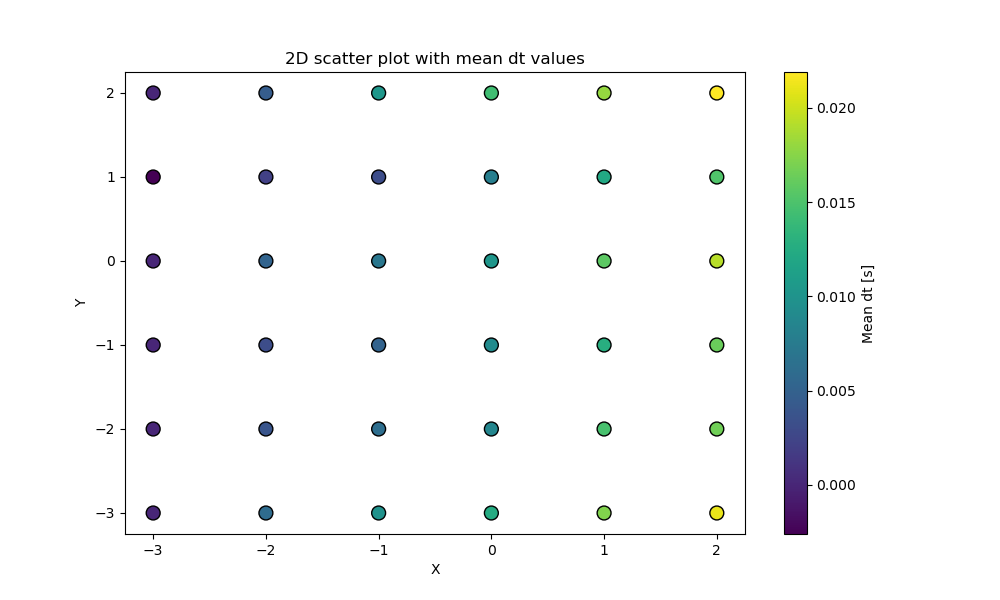

In [4]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(big_df['lon'], big_df['lat'], c=big_df['mean'], cmap='viridis', s=100, edgecolor='k')

# Add a colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('Mean dt [s]')

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D scatter plot with mean dt values')

# Show the plot
plt.show()

### Contour plot (only works if HS come from one side)

XXX Needs a bit of more work/thought 

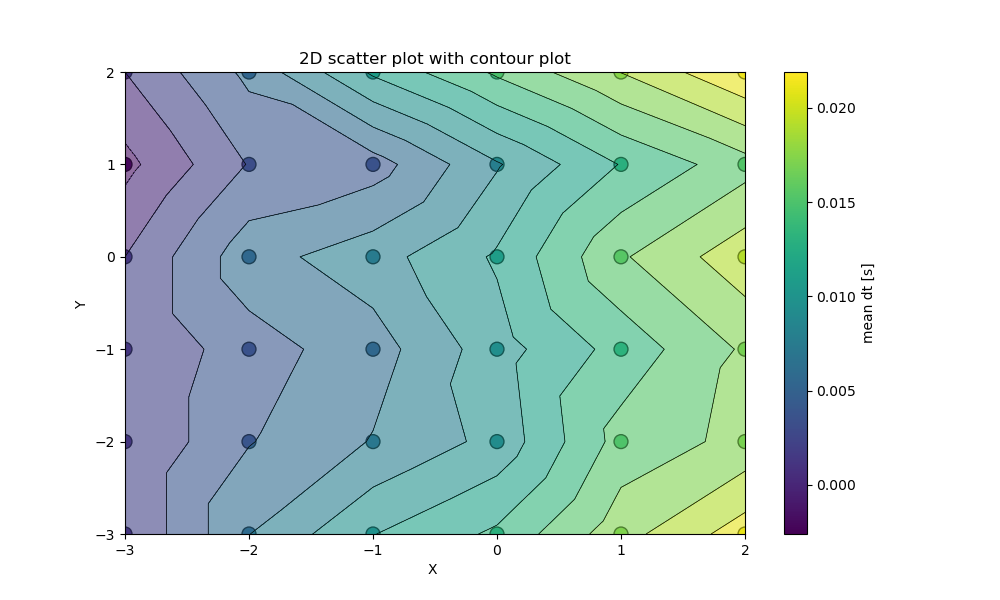

In [5]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(big_df['lon'], big_df['lat'], c=big_df['mean'], cmap='viridis', s=100, edgecolor='k')

# Add a colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('mean dt [s]')

# Create the contour plot
contour = plt.tricontour(big_df['lon'], big_df['lat'], big_df['mean'], levels=14, linewidths=0.5, colors='k')
contourf = plt.tricontourf(big_df['lon'], big_df['lat'], big_df['mean'], levels=14, cmap='viridis', alpha=0.6)

# Add labels and title
plt.xlabel('X ')
plt.ylabel('Y ')
plt.title('2D scatter plot with contour plot')

# Show the plot
plt.show()